# Student Info
## Chinese Name: Li Anran
## English Name: Yuki
## ID:C00292764

# Introduction

This project analyzes the "Life Expectancy" dataset from the World Health Organization, which records data from 193 countries between 2000 and 2015, including various factors that may influence lifespan.

Life expectancy was chosen as the target variable due to its comprehensive reflection of a country's health, economic, and medical conditions. As a continuous numerical variable, it is well-suited for regression modeling and prediction tasks.

To accurately predict life expectancy and identify key influencing factors, we employed and compared three regression models: Linear Regression (as an interpretable baseline), Decision Tree Regression (to capture non-linear relationships), and Random Forest Regression (an ensemble method to enhance robustness and accuracy). The goal is to build a reliable predictive framework and uncover actionable insights into the determinants of global life expectancy.

In [20]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler,MinMaxScaler
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import LSTM,Input, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import MultiHeadAttention, LayerNormalization, GlobalAveragePooling1D

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/rupakroy/lstm-datasets-multivariate-univariate/pollution_test_data1.csv
/kaggle/input/datasets/rupakroy/lstm-datasets-multivariate-univariate/LSTM-Multivariate_pollution.csv


# Exploring Data

## A first look at the data
This dataset contains multivariate time series data for air pollution forecasting, combining pollution measurements with meteorological factors.

* date: String representing the date and time of data collection (format: YYYY-MM-DD HH:MM:SS)
* pollution: Float value of PM2.5 concentration (unit: μg/m³) - Target variable for forecasting
* dew: Float value of dew point temperature (unit: °C)
* temp: Float value of air temperature (unit: °C)
* press: Float value of atmospheric pressure (unit: hPa)
* wnd_dir: Categorical string feature representing wind direction (e.g., NE, SE, NW, SW)
* wnd_spd: Float value of wind speed (unit: m/s)
* snow: Float value of snowfall amount (unit: mm)
* rain: Float value of rainfall amount (unit: mm)

In conclusion,we have 1 categorical variable: wind direction (wnd_dir), 1 datetime variable: date,7 numerical variables (float): pollution, dew, temp, press, wnd_spd, snow, rain.

In [21]:
df_train = pd.read_csv("/kaggle/input/datasets/rupakroy/lstm-datasets-multivariate-univariate/LSTM-Multivariate_pollution.csv")
df_test = pd.read_csv("/kaggle/input/datasets/rupakroy/lstm-datasets-multivariate-univariate/pollution_test_data1.csv")
df_train.head(5)

,date,pollution,dew,temp,press,wnd_dir,wnd_spd,snow,rain
0,2010-01-02 00:00:00,129.0,-16,-4.0,1020.0,SE,1.79,0,0
1,2010-01-02 01:00:00,148.0,-15,-4.0,1020.0,SE,2.68,0,0
2,2010-01-02 02:00:00,159.0,-11,-5.0,1021.0,SE,3.57,0,0
3,2010-01-02 03:00:00,181.0,-7,-5.0,1022.0,SE,5.36,1,0
4,2010-01-02 04:00:00,138.0,-7,-5.0,1022.0,SE,6.25,2,0


No Missing Values

In [22]:
print(df_train.isnull().sum())
print(df_train.dtypes)

date         0
pollution    0
dew          0
temp         0
press        0
wnd_dir      0
wnd_spd      0
snow         0
rain         0
dtype: int64
date          object
pollution    float64
dew            int64
temp         float64
press        float64
wnd_dir       object
wnd_spd      float64
snow           int64
rain           int64
dtype: object


From the description we can see:

* Wind speed has extreme outliers: Maximum value 585 is 26 times higher than normal values (21.9), requires 99th percentile capping

* Precipitation data shows zero inflation: 75th percentile is 0, meaning no precipitation most of the time, requires creating binary features for rain/snow presence

* Large scale differences among features: Pollution (0-994), Wind speed (0-585), Temperature (-19-42) have different units/ranges, requires normalization

In [23]:
df_train.describe()

,pollution,dew,temp,press,wnd_spd,snow,rain
count,43800.000000,43800.000000,43800.000000,43800.000000,43800.000000,43800.000000,43800.000000
mean,94.013516,1.828516,12.459041,1016.447306,23.894307,0.052763,0.195023
std,92.252276,14.429326,12.193384,10.271411,50.022729,0.760582,1.416247
min,0.000000,-40.000000,-19.000000,991.000000,0.450000,0.000000,0.000000
25%,24.000000,-10.000000,2.000000,1008.000000,1.790000,0.000000,0.000000
50%,68.000000,2.000000,14.000000,1016.000000,5.370000,0.000000,0.000000
75%,132.250000,15.000000,23.000000,1025.000000,21.910000,0.000000,0.000000
max,994.000000,28.000000,42.000000,1046.000000,585.600000,27.000000,36.000000


The pollution index exhibits a distinct right-skewed distribution, with the mean (94) significantly exceeding the median (68). While most values are concentrated between 0 and 200, a long tail extends up to 994. To preserve the physical volatility of the raw data, we opted not to apply a log transformation. Instead, we utilized MinMaxScaler to scale the data to the [0, 1] range, ensuring that extreme peak values continue to provide critical training signals for the model.

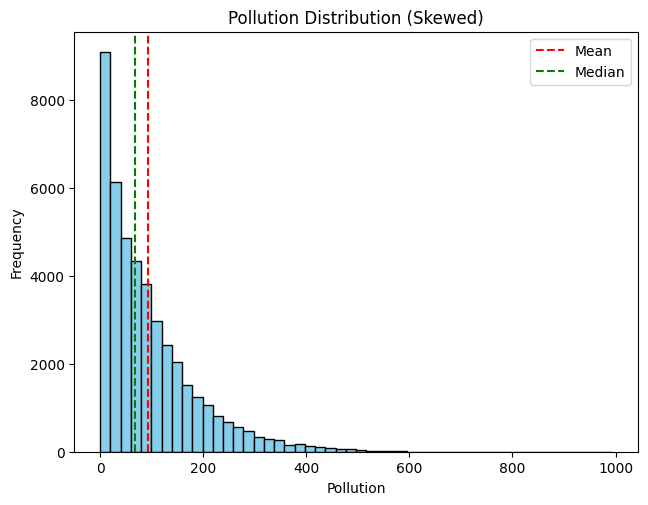

In [24]:
plt.figure(figsize=[16,12])

plt.subplot(221)
plt.title("Pollution Distribution (Skewed)")
plt.hist(df_train['pollution'], bins=50, color='skyblue', edgecolor='black')
plt.axvline(df_train['pollution'].mean(), color='red', linestyle='--', label='Mean')
plt.axvline(df_train['pollution'].median(), color='green', linestyle='--', label='Median')
plt.xlabel('Pollution')
plt.ylabel('Frequency')
plt.legend()

99% of wind speed values fall within the normal range of 0-22 m/s, 
but there are extreme outliers reaching 585 m/s. These outliers, though only 1% of the data,need to be capped at the 99th percentile to prevent model instability.

Text(0, 0.5, 'Wind Speed')

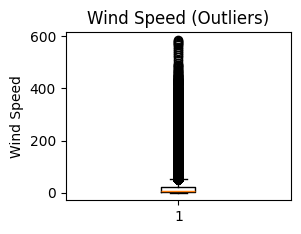

In [25]:
plt.subplot(222)
plt.title("Wind Speed (Outliers)")
plt.boxplot(df_train['wnd_spd'])
plt.ylabel('Wind Speed')

Rainfall data exhibits typical zero-inflation characteristics, with approximately 85% of days having no rain. 
Binary features need to be created to help the model distinguish between "rain" and "no rain" conditions.

Text(0, 0.5, 'Count')

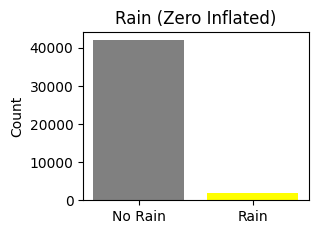

In [26]:
plt.subplot(223)
plt.title("Rain (Zero Inflated)")
rain_zero = (df_train['rain'] == 0).sum()
rain_nonzero = (df_train['rain'] > 0).sum()
plt.bar(['No Rain', 'Rain'], [rain_zero, rain_nonzero], color=['gray', 'yellow'])
plt.ylabel('Count')

Snowfall data shows similar zero-inflation pattern, with about 98% of days having no snow. 
Binary features are necessary to help the model understand the rarity of snowfall events.

Text(0, 0.5, 'Count')

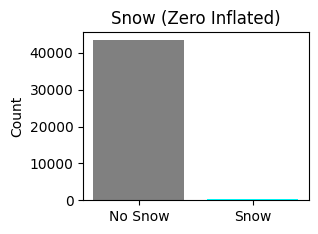

In [27]:
plt.subplot(224)
plt.title("Snow (Zero Inflated)")
snow_zero = (df_train['snow'] == 0).sum()
snow_nonzero = (df_train['snow'] > 0).sum()
plt.bar(['No Snow', 'Snow'], [snow_zero, snow_nonzero], color=['gray', 'cyan'])
plt.ylabel('Count')

# Processing Data

## Processing Train Data

Cap training set wind speed values using the 99th percentile threshold,
replacing extreme outliers with the threshold value.This solves the extreme outlier problem in wind speed data.

In [28]:
wind_99_train = df_train['wnd_spd'].quantile(0.99)
df_train['wnd_spd'] = df_train['wnd_spd'].clip(upper=wind_99_train)

Create binary features from original precipitation data: 1 for precipitation, 0 for no precipitation. This solves the zero-inflation problem and helps the model distinguish between rainy and non-rainy days.

In [29]:
df_train['rain_binary'] = (df_train['rain'] > 0).astype(int)
df_train['snow_binary'] = (df_train['snow'] > 0).astype(int)

Since the wind direction is a categorical feature containing string values like 'NE' and 'NW', which deep learning models cannot process directly, we implemented a numerical mapping dictionary. By assigning specific integer indices to each category

In [30]:
mapping = {'NE': 0, 'SE': 1, 'NW': 2, 'cv': 3}
df_train['wnd_dir'] = df_train['wnd_dir'].map(mapping)

Using MinMaxScaler normalize all features, including pollution and meteorological variables, within the range [0, 1]. This ensures that all inputs reside on a unified scale, preventing features with larger numerical magnitudes from dominating the LSTM's weight updates and facilitating faster convergence during training.

In [31]:
scaler = MinMaxScaler()
features = ['pollution', 'dew', 'temp', 'press', 'wnd_spd', 'wnd_dir', 'rain', 'snow']
df_train[features] = scaler.fit_transform(df_train[features])

## Processing Test Data

Same for test set

In [32]:
df_test['wnd_spd'] = df_test['wnd_spd'].clip(upper=wind_99_train)

In [33]:
df_test['rain_binary'] = (df_test['rain'] > 0).astype(int)
df_test['snow_binary'] = (df_test['snow'] > 0).astype(int)

In [34]:
df_test['wnd_dir'] = df_test['wnd_dir'].map(mapping)

In [35]:
df_test[features] = scaler.transform(df_test[features])

## View Processing Results

Check processed data statistics to confirm all features are properly normalized, binary features have reasonable distributions, and outlier issues are resolved.

In [36]:
print(df_train[['pollution', 'wnd_spd', 'rain', 'snow']].describe())


          pollution       wnd_spd          rain          snow
count  43800.000000  43800.000000  43800.000000  43800.000000
mean       0.094581      0.084538      0.005417      0.001954
std        0.092809      0.168391      0.039340      0.028170
min        0.000000      0.000000      0.000000      0.000000
25%        0.024145      0.004988      0.000000      0.000000
50%        0.068410      0.018312      0.000000      0.000000
75%        0.133048      0.079875      0.000000      0.000000
max        1.000000      1.000000      1.000000      1.000000


## Prepare Data

To adapt to the LSTM model, the tabular data was converted into 3D time series. We set past = 11, utilizing the meteorological features of the past 11 hours to predict the pollution value for the next 1 hour.

Regarding feature selection, historical pollution data was excluded from the input X. The purpose of this was to eliminate the strong correlation interference and data leakage of the target variable itself, thereby more clearly observing the impact of meteorological factors on air quality.

In [37]:
feature_cols = ['dew', 'temp', 'press', 'wnd_spd', 'wnd_dir', 'rain', 'snow']

y_train_all = df_train['pollution'].values
y_test_all = df_test['pollution'].values

train = np.array(df_train[feature_cols])
test = np.array(df_test[feature_cols])

past = 11
future = 1

X_train, y_train = [], []
for i in range(past, len(train) - future + 1):
    X_train.append(train[i-past:i, :])
    y_train.append(y_train_all[i+future-1])
X_train, y_train = np.array(X_train), np.array(y_train)

X_test, y_test = [], []
for i in range(past, len(test) - future + 1):
    X_test.append(test[i-past:i, :])
    y_test.append(y_test_all[i+future-1])
X_test, y_test = np.array(X_test), np.array(y_test)

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")

X_train: (43789, 11, 7), y_train: (43789,)
X_test: (335, 11, 7), y_test: (335,)


# Modeling

## LSTM

We chose an LSTM network because the fluctuations in PM2.5 levels are highly dependent on the historical progression of weather patterns over the past 11 hours. A stacked architecture (32 and 16 units) was implemented to allow the model to first interpret basic meteorological trends and then extract deeper correlations that trigger pollution peaks. By incorporating a Dropout (0.1) layer, the model gains the robustness needed to predict the next hour's pollution values based solely on weather indicators, effectively mapping complex atmospheric dynamics to air quality outcomes.

In [38]:
model = Sequential([
    
    LSTM(32, activation='relu', return_sequences=True, 
         input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    
    LSTM(16, activation='relu', return_sequences=False),
    
    Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=150,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1,
    shuffle=False
)

train_loss, train_mae = model.evaluate(X_train, y_train, verbose=0)
print(f"\nTrain_MAE: {train_mae:.4f}")

test_loss, test_mae = model.evaluate(X_test, y_test, verbose=0)
print(f"Test_MAE: {test_mae:.4f}")


Epoch 1/150


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1232/1232 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - loss: 0.0077 - mae: 0.0638 - val_loss: 0.0099 - val_mae: 0.0622
Epoch 2/150
1232/1232 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0069 - mae: 0.0584 - val_loss: 0.0102 - val_mae: 0.0622
Epoch 3/150
1232/1232 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 0.0069 - mae: 0.0583 - val_loss: 0.0102 - val_mae: 0.0624
Epoch 4/150
1232/1232 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 0.0067 - mae: 0.0572 - val_loss: 0.0102 - val_mae: 0.0628
Epoch 5/150
1232/1232 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0068 - mae: 0.0579 - val_loss: 0.0104 - val_mae: 0.0635
Epoch 6/150
1232/1232 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0067 - mae: 0.0577 - val_loss: 0.0102 - val_mae: 0.0632
Epoch 7/150
1232/1232 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0066 - mae: 0.0572 - val_loss: 0.0097 - val_mae: 0.0612
Epoch 8/150
1232/1232 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0065 - mae: 0.0560 - val_loss: 0.0093 - val_mae: 0.0595
Epoch 9/150
1232/1232 ━━━━━━━━━━━━━━━━━━━━ 

Early experimental results showed a significant gap between training loss and validation loss, with validation loss being considerably lower. Through systematic investigation, four root causes were identified and addressed:

* Log1p Transformation Issue

  Applying `np.log1p` to the target variable `pollution` compressed the data range, artificially reducing training loss and making it unusually low from the start.

* Validation Set Distribution Bias

  As shown in the target variable distribution plot, the validation set (orange, the last 10% of the data) exhibits overall lower pollution values and less fluctuation compared to the training set (blue, the first 90% of the data). Since `validation_split=0.1` defaults to taking the last 10% as the validation set, this portion of data is inherently easier to predict, further lowering validation loss.

* Dropout Regularization Effect

  The model used two Dropout layers (rate=0.2), which randomly deactivate 20% of neurons during training to enhance generalization, intentionally increasing training loss. During validation, Dropout is disabled, allowing the model to utilize its full capacity and achieve lower loss.

* Historical Pollution as Input Feature

  In the early code, `pollution` was mistakenly included as an input feature, allowing the model to directly "see" the previous hour's pollution value to predict the next hour, making the task artificially easy and causing abnormally low training loss. After correction, the model must learn patterns solely from meteorological features, restoring training loss to a normal level.

After these adjustments and analysis, the training and validation loss curves stabilized into a healthy pattern, confirming that the model is properly tuned and learning effectively.

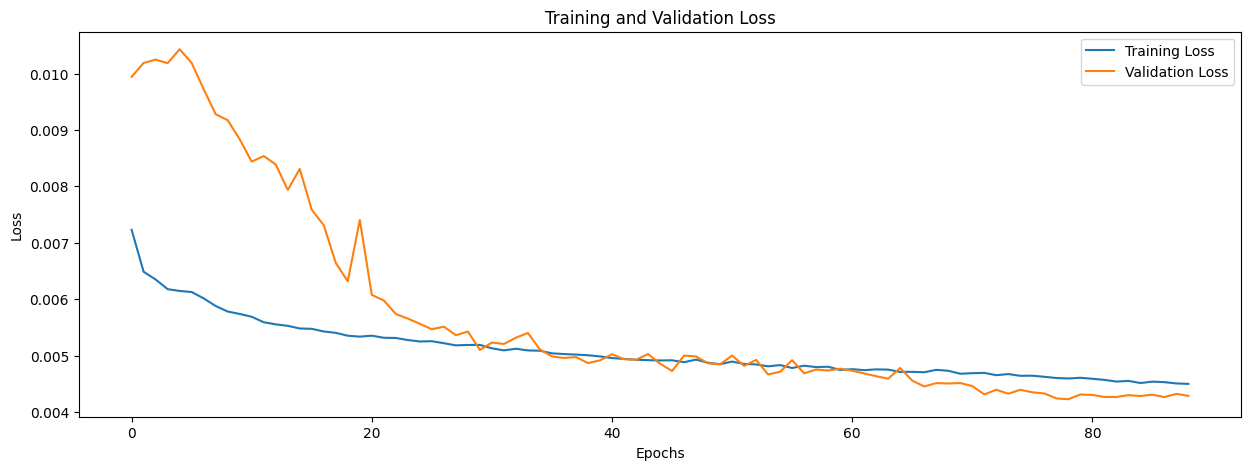

In [39]:
plt.figure(figsize=(15,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

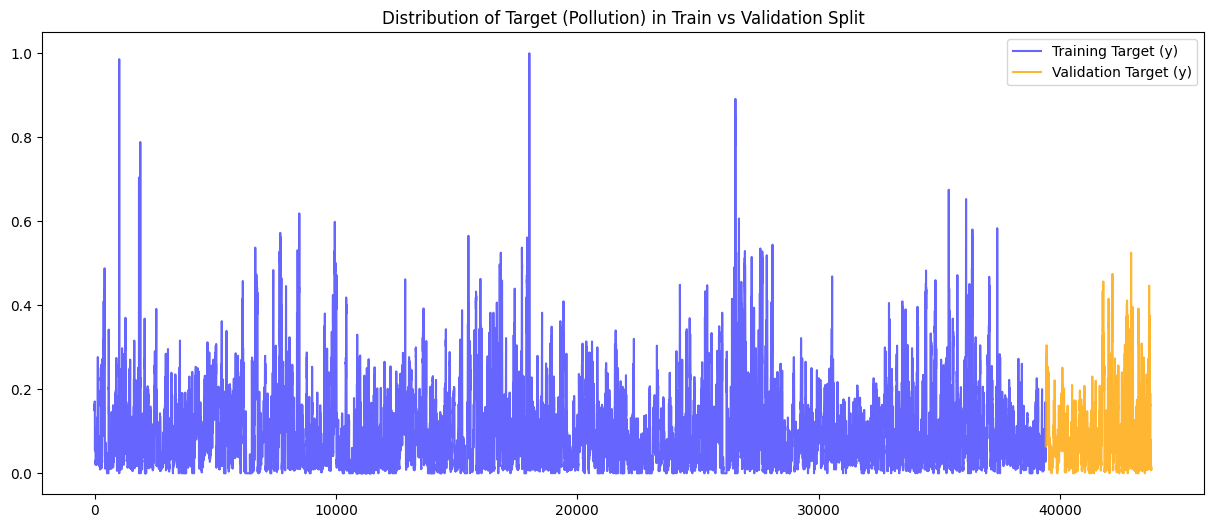

In [40]:
import matplotlib.pyplot as plt

split = int(len(y_train) * 0.9)

plt.figure(figsize=(15, 6))
plt.plot(range(split), y_train[:split], label='Training Target (y)', color='blue', alpha=0.6)
plt.plot(range(split, len(y_train)), y_train[split:], label='Validation Target (y)', color='orange', alpha=0.8)
plt.title('Distribution of Target (Pollution) in Train vs Validation Split')
plt.legend()
plt.show()

The figure compares actual pollution values with model predictions on the test set. The predicted values closely follow the actual trends, demonstrating that the model has effectively learned the relationship between meteorological features and pollution levels.

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step


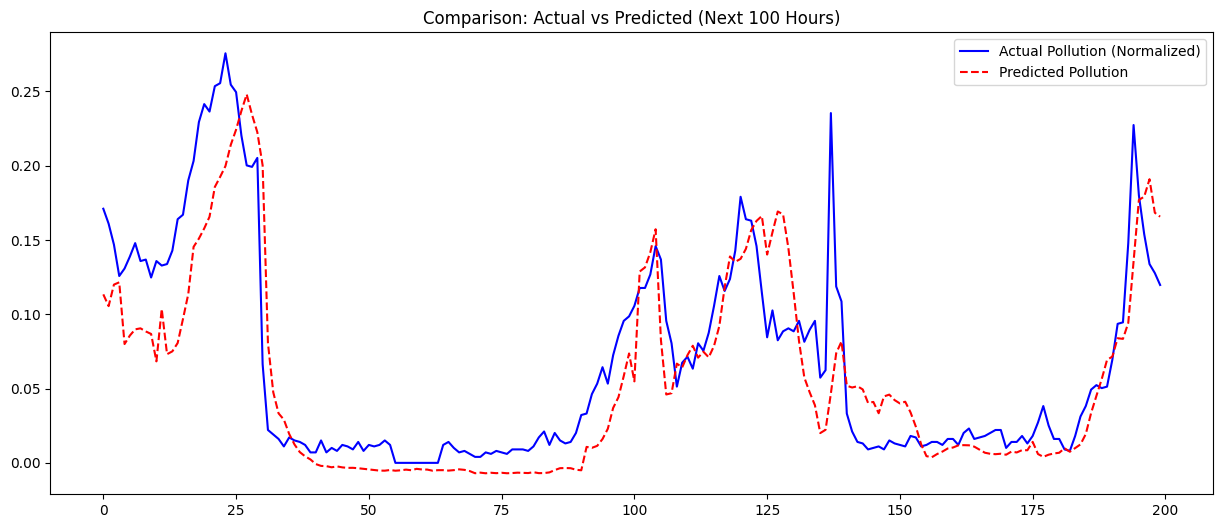

In [41]:
test_preds = model.predict(X_test)
plt.figure(figsize=(15, 6))
plt.plot(y_test[:200], label='Actual Pollution (Normalized)', color='blue')
plt.plot(test_preds[:200], label='Predicted Pollution', color='red', linestyle='--')
plt.title('Comparison: Actual vs Predicted (Next 100 Hours)')
plt.legend()
plt.show()